# Data Preprocessing

## Objective

The original dataset contains a validation set with only 16 images, which is insufficient for reliable model validation.

In this notebook, the original training and validation sets will be combined and a new stratified validation split will be created. The preprocessing pipeline, data augmentation, and PyTorch DataLoaders will also be prepared for model training.

In [ ]:
# ==========================================
# Import Required Libraries
# ==========================================

import random
from pathlib import Path

import numpy as np
import pandas as pd

from PIL import Image

import torch
from torchvision import transforms

from sklearn.model_selection import train_test_split

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
import torch

print("PyTorch Version:", torch.__version__)
print("GPU Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch Version: 2.11.0+cu128
GPU Available: True
GPU: Tesla T4


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
from pathlib import Path
PROJECT_DIR = Path("/content/drive/MyDrive/pneumonia_project")

DATA_DIR = PROJECT_DIR / "data" / "chest_xray"

MODELS_DIR = PROJECT_DIR / "models"

OUTPUT_DIR = PROJECT_DIR / "outputs"

print("Project Directory:", PROJECT_DIR)
print("Dataset Exists:", DATA_DIR.exists())

Project Directory: /content/drive/MyDrive/pneumonia_project
Dataset Exists: True


## Dataset Reorganization

The original dataset contains:

- A large training set
- A validation set containing only 16 images
- A separate test set

Since the validation set is too small for reliable model evaluation, the original training and validation sets will be merged.

A new stratified validation split will then be created while keeping the original test set completely untouched.

This ensures:

- Better validation performance estimation
- Preserved class distribution
- Fair final evaluation on unseen test data"

In [ ]:
import pandas as pd

def collect_image_data(split, label):
    folder = DATA_DIR / split / label

    data = []

    for image_path in folder.iterdir():
        data.append({
            "image_path": str(image_path),
            "label": label,
            "original_split": split
        })

    return data


# Collect data from train and validation only
image_data = []

for split in ["train", "val"]:
    for label in ["NORMAL", "PNEUMONIA"]:
        image_data.extend(collect_image_data(split, label))

# Create DataFrame
data_df = pd.DataFrame(image_data)

print("Dataset Shape:", data_df.shape)

print("\nClass Distribution:")
print(data_df["label"].value_counts())

data_df.head()

Dataset Shape: (5232, 3)

Class Distribution:
label
PNEUMONIA    3883
NORMAL       1349
Name: count, dtype: int64


,image_path,label,original_split
0,/content/drive/MyDrive/pneumonia_project/data/...,NORMAL,train
1,/content/drive/MyDrive/pneumonia_project/data/...,NORMAL,train
2,/content/drive/MyDrive/pneumonia_project/data/...,NORMAL,train
3,/content/drive/MyDrive/pneumonia_project/data/...,NORMAL,train
4,/content/drive/MyDrive/pneumonia_project/data/...,NORMAL,train


In [ ]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    data_df,
    test_size=0.15,
    stratify=data_df["label"],
    random_state=42
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
print("Train:", train_df["label"].value_counts().to_dict())
print("Val:  ", val_df["label"].value_counts().to_dict())

Train: {'PNEUMONIA': 3300, 'NORMAL': 1147}
Val:   {'PNEUMONIA': 583, 'NORMAL': 202}


In [ ]:
# ==========================================
# Verify Train-Validation Split
# ==========================================

print("=" * 50)
print("TRAINING SET")
print("=" * 50)

print(f"Total Images : {len(train_df)}\n")

print(train_df["label"].value_counts())

print("\nPercentage Distribution")

print((train_df["label"].value_counts(normalize=True) * 100).round(2))


print("\n" + "=" * 50)
print("VALIDATION SET")
print("=" * 50)

print(f"Total Images : {len(val_df)}\n")

print(val_df["label"].value_counts())

print("\nPercentage Distribution")

print((val_df["label"].value_counts(normalize=True) * 100).round(2))

TRAINING SET
Total Images : 4447

label
PNEUMONIA    3300
NORMAL       1147
Name: count, dtype: int64

Percentage Distribution
label
PNEUMONIA    74.21
NORMAL       25.79
Name: proportion, dtype: float64

VALIDATION SET
Total Images : 785

label
PNEUMONIA    583
NORMAL       202
Name: count, dtype: int64

Percentage Distribution
label
PNEUMONIA    74.27
NORMAL       25.73
Name: proportion, dtype: float64


In [ ]:
# ==========================================
# Check for Data Leakage
# ==========================================

train_paths = set(train_df["image_path"])
val_paths = set(val_df["image_path"])

overlap = train_paths.intersection(val_paths)

print("Number of overlapping images:", len(overlap))

Number of overlapping images: 0


## Train-Validation Split

The original training and validation datasets were merged and a new stratified validation split was created.

### Final Dataset Split

- Training Set: 4,447 images (85%)
- Validation Set: 785 images (15%)
- Test Set: 624 images (unchanged)

### Observations

- Stratified sampling preserved the original class distribution across both datasets.
- No overlap exists between the training and validation sets, preventing data leakage.
- The original test set remains untouched and will be used only for final model evaluation.

In [ ]:
test_data = collect_image_data("test", "NORMAL") + collect_image_data("test", "PNEUMONIA")

test_df = pd.DataFrame(test_data)

# Reset index
test_df = test_df.reset_index(drop=True)

print("Test Dataset Shape:", test_df.shape)

print("\nClass Distribution:")
print(test_df["label"].value_counts())

test_df.head()

Test Dataset Shape: (624, 3)

Class Distribution:
label
PNEUMONIA    390
NORMAL       234
Name: count, dtype: int64


,image_path,label,original_split
0,/content/drive/MyDrive/pneumonia_project/data/...,NORMAL,test
1,/content/drive/MyDrive/pneumonia_project/data/...,NORMAL,test
2,/content/drive/MyDrive/pneumonia_project/data/...,NORMAL,test
3,/content/drive/MyDrive/pneumonia_project/data/...,NORMAL,test
4,/content/drive/MyDrive/pneumonia_project/data/...,NORMAL,test


In [ ]:
SPLIT_DIR = PROJECT_DIR / "data_splits"
SPLIT_DIR.mkdir(exist_ok=True)

train_df.to_csv(SPLIT_DIR / "train_split.csv", index=False)
val_df.to_csv(SPLIT_DIR / "val_split.csv", index=False)
test_df.to_csv(SPLIT_DIR / "test_split.csv", index=False)

print("✅ Saved all dataset splits.")

✅ Saved all dataset splits.


# Image Preprocessing

Before training the model, all images must be transformed into a consistent format compatible with the pretrained CNN.

The preprocessing pipeline will:

- Resize all images to **224 × 224** pixels.
- Convert grayscale X-ray images to **3-channel RGB** format.
- Normalize pixel values using ImageNet statistics.
- Apply data augmentation only to the training dataset to improve model generalization.

In [ ]:
import torchvision.transforms as transforms
from PIL import Image

In [ ]:
# ==========================================
# Image Configuration

IMG_SIZE = 224

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

## Image Transformations

Two separate transformation pipelines are defined:

- **Training Transform:** Includes data augmentation to improve model generalization and reduce overfitting.
- **Validation/Test Transform:** Applies only preprocessing operations so evaluation is performed on unaltered images.

The preprocessing steps include resizing, converting grayscale images to RGB, converting images to tensors, and normalizing pixel values using ImageNet statistics.

In [ ]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05)
    ),
    transforms.ColorJitter(
        brightness=0.10,
        contrast=0.10
    ),
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

## Custom PyTorch Dataset

A custom dataset class is implemented to load chest X-ray images directly from the DataFrames.

The dataset performs the following tasks:

- Reads the image path from the DataFrame.
- Loads the image using PIL.
- Applies the specified preprocessing and augmentation pipeline.
- Converts class labels into numerical values:
  - NORMAL → 0
  - PNEUMONIA → 1

This custom dataset integrates seamlessly with PyTorch DataLoaders for efficient mini-batch training.

In [ ]:
from torch.utils.data import Dataset
from PIL import Image

class ChestXrayDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

        self.label_map = {
            "NORMAL": 0,
            "PNEUMONIA": 1
        }

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        image = Image.open(row["image_path"]).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = self.label_map[row["label"]]

        return image, label


In [ ]:
train_dataset = ChestXrayDataset(train_df, transform=train_transform)
val_dataset = ChestXrayDataset(val_df, transform=val_test_transform)
test_dataset = ChestXrayDataset(test_df, transform=val_test_transform)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Val dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

Train dataset size: 4447
Val dataset size: 785
Test dataset size: 624


In [21]:
print("Training Images :", len(train_dataset))
print("Validation Images:", len(val_dataset))
print("Testing Images :", len(test_dataset))

Training Images : 4447
Validation Images: 785
Testing Images : 624


In [22]:
img, label = train_dataset[0]
print("Image tensor shape:", img.shape)
print("Label:", label)

Image tensor shape: torch.Size([3, 224, 224])
Label: 0


## Create PyTorch DataLoaders

PyTorch DataLoaders are used to efficiently load images in mini-batches during training and evaluation.

The training DataLoader shuffles the data at the beginning of every epoch to improve model generalization.

Validation and test DataLoaders do not shuffle the data because they are used only for evaluation.

In [23]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"Training batches   : {len(train_loader)}")
print(f"Validation batches : {len(val_loader)}")
print(f"Testing batches    : {len(test_loader)}")

Training batches   : 139
Validation batches : 25
Testing batches    : 20


In [25]:
print(f"Training batches   : {len(train_loader)}")
print(f"Validation batches : {len(val_loader)}")
print(f"Testing batches    : {len(test_loader)}")

Training batches   : 139
Validation batches : 25
Testing batches    : 20


In [24]:
images, labels = next(iter(train_loader))
print("Batch image shape:", images.shape)
print("Batch labels shape:", labels.shape)
print("Sample labels:", labels[:10])

Batch image shape: torch.Size([32, 3, 224, 224])
Batch labels shape: torch.Size([32])
Sample labels: tensor([1, 1, 1, 1, 0, 1, 1, 0, 0, 1])


## DataLoader Verification

A batch of images was successfully loaded from the training DataLoader.

### Observations

- Batch size: **32**
- Image shape: **3 × 224 × 224**
- All images were successfully converted to RGB.
- Labels were correctly encoded as:
  - **0 → NORMAL**
  - **1 → PNEUMONIA**

The output confirms that the preprocessing pipeline and custom dataset are functioning correctly and are ready for model training.

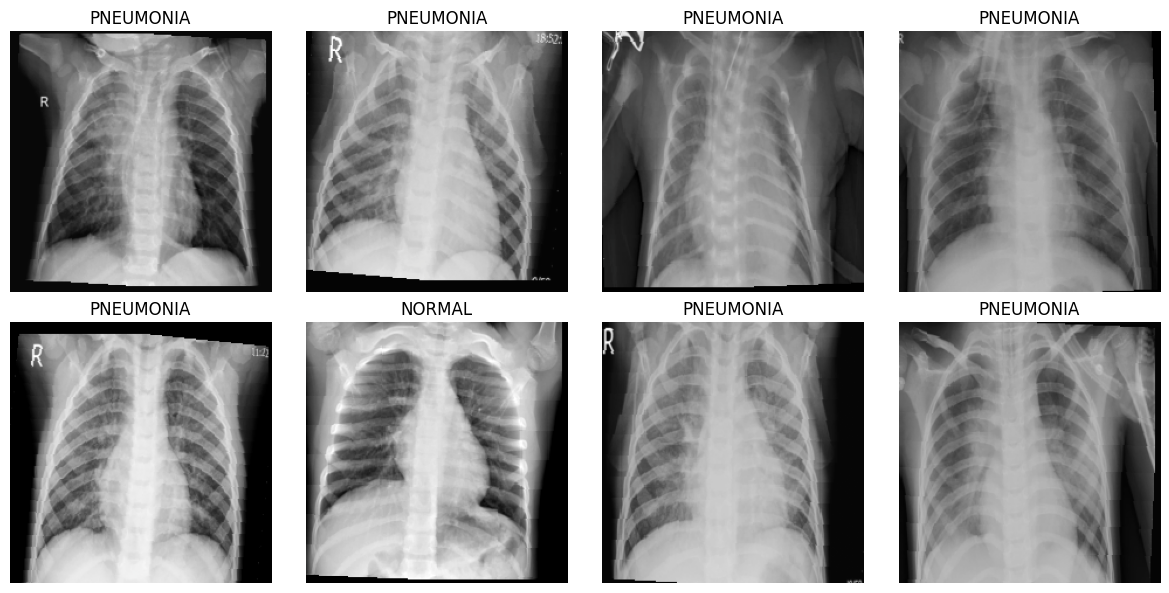

In [26]:
import matplotlib.pyplot as plt
import torchvision

# Denormalization function
def denormalize(img):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return img * std + mean

# Get one batch
images, labels = next(iter(train_loader))

# Show first 8 images
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title("NORMAL" if labels[i] == 0 else "PNEUMONIA")
    ax.axis("off")

plt.tight_layout()
plt.show()

## Preprocessing Summary

The preprocessing pipeline for this project is finalized with the following configuration:

- Image Size: **224 × 224**
- Color Mode: **RGB (converted from grayscale when required)**
- Training Augmentations:
  - Random Rotation (±10°)
  - Random Affine (translation and scaling)
  - Brightness and Contrast Jitter
- Validation/Test Processing:
  - Resize
  - RGB Conversion
  - Normalization
- Normalization:
  - Mean: `[0.485, 0.456, 0.406]`
  - Standard Deviation: `[0.229, 0.224, 0.225]`
- Batch Size: **32**

The preprocessing pipeline is now ready for transfer learning using a pretrained CNN.